<a href="https://colab.research.google.com/github/Atherizz/PCVK_2026/blob/main/week_5/week5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Modul 5 - Histogram, Histogram Equalization, dan Dithering
Pengolahan Citra dan Visi Komputer

In [6]:
import sys, platform, hashlib, datetime, zoneinfo

NAMA = 'Savero Athallah Hardiana Putra'
NIM  = '244107020116'

N = int(NIM[-3:])
PARAM = {
    'bins' : 2 ** ((N % 4) + 3),
    'clip' : round(1.0 + (N % 5) * 0.5, 1),
    'tile' : (N % 4) + 2,
    'L'    : 2 ** ((N % 3) + 1),
}
waktu = datetime.datetime.now(zoneinfo.ZoneInfo('Asia/Jakarta'))

print('NAMA   :', NAMA)
print('NIM    :', NIM, '| N =', N)
for k, v in PARAM.items():
    print('%-6s :' % k, v)
print('WAKTU  :', waktu.strftime('%Y-%m-%d %H:%M:%S %Z'))
print('SISTEM :', sys.version.split()[0], platform.platform())
kunci = NIM + '|' + waktu.strftime('%Y-%m-%d')
print('TOKEN  :', hashlib.sha256(kunci.encode()).hexdigest()[:16])

NAMA   : Savero Athallah Hardiana Putra
NIM    : 244107020116 | N = 116
bins   : 8
clip   : 1.5
tile   : 2
L      : 8
WAKTU  : 2026-09-30 19:57:33 WIB
SISTEM : 3.13.15 Linux-6.6.122+-x86_64-with-glibc2.39
TOKEN  : d5ef1fd3beec4355


## Persiapan: Mount Drive dan Import Library

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

PATH = '/content/drive/MyDrive/PCVK'

# E-1. PERCOBAAN HISTOGRAM

**Langkah 3 modul**: membuat histogram citra secara manual (menghitung
jumlah kemunculan tiap nilai piksel dengan perulangan), lalu menampilkannya
sebagai grafik batang. Tahap 1 memakai `lena.jpg`, tahap 2 memakai `KTM1b.jpg`.

In [11]:
def histogram_manual(channel):
    """Menghitung histogram 1 channel (nilai 0-255) dengan cara manual."""
    h = np.zeros(256, dtype=np.int64)
    for baris in channel:
        for nilai in baris:
            h[nilai] += 1
    return h

def tampilkan_histogram_rgb(path_gambar, judul):
    img_bgr = cv.imread(path_gambar)
    img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)

    hist_r = histogram_manual(img_rgb[:, :, 0])
    hist_g = histogram_manual(img_rgb[:, :, 1])
    hist_b = histogram_manual(img_rgb[:, :, 2])

    fig, axs = plt.subplots(1, 3, figsize=(15, 4), sharex=True, sharey=True)
    fig.suptitle(judul)
    axs[0].bar(range(256), hist_r, color='red')
    axs[1].bar(range(256), hist_g, color='green')
    axs[2].bar(range(256), hist_b, color='blue')
    fig.text(0.5, 0.02, 'Intensitas Warna', ha='center')
    fig.text(0.08, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
    plt.show()
    return img_rgb

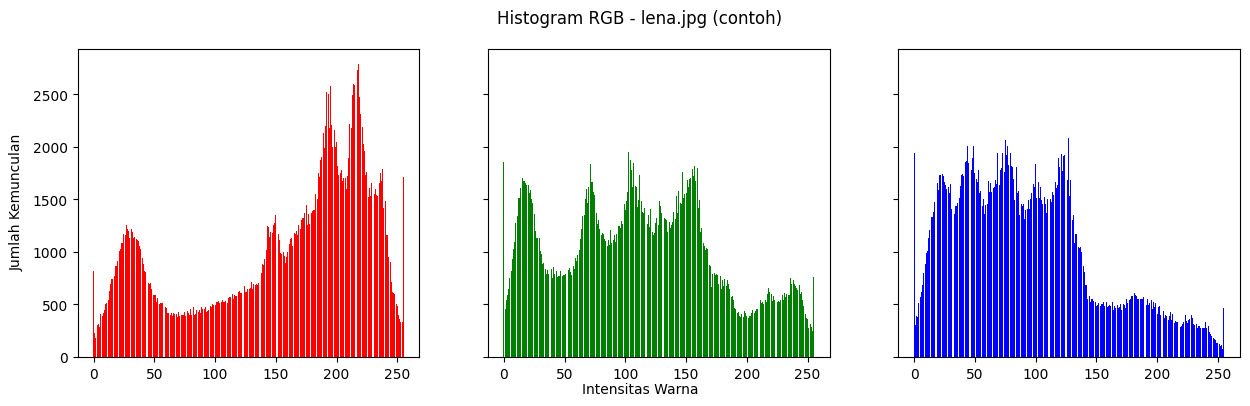

In [13]:
_ = tampilkan_histogram_rgb(PATH + '/lena.jpeg', 'Histogram RGB - lena.jpg (contoh)')

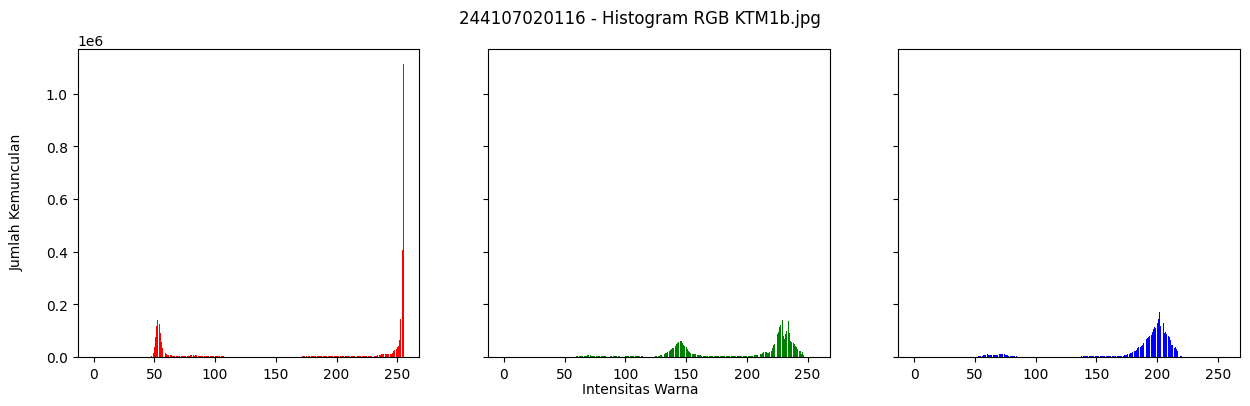

In [15]:
_ = tampilkan_histogram_rgb(PATH + '/KTM1b.jpg', NIM + ' - Histogram RGB KTM1b.jpg')

## Pertanyaan Praktikum E-1

**1. Bandingkan histogram manual dengan `numpy.histogram` dan `cv.calcHist`.**
Selisih maksimum antar hasil harus nol. Citra tetap berwarna (BGR), tiap kanal
dibandingkan sendiri-sendiri — sama seperti histogram RGB pada langkah
sebelumnya. Dilakukan dulu pada `lena.jpg`, lalu pada `KTM1b.jpg`.

In [16]:
def bandingkan_3_metode(path_gambar, nama_file):
    bgr = cv.imread(path_gambar)
    kanal = cv.split(bgr)              # urutan OpenCV: Biru, Hijau, Merah
    nama_kanal = ['Biru', 'Hijau', 'Merah']

    print(f'--- {nama_file} ---')
    for k, nama in zip(kanal, nama_kanal):
        hist_manual = histogram_manual(k)
        hist_numpy, _ = np.histogram(k, bins=256, range=(0, 256))
        hist_cv = cv.calcHist([k], [0], None, [256], [0, 256]).flatten()

        selisih_manual_numpy = np.max(np.abs(hist_manual - hist_numpy))
        selisih_manual_cv    = np.max(np.abs(hist_manual - hist_cv))

        print(f'Kanal {nama}: selisih manual vs numpy.histogram = {selisih_manual_numpy}, '
              f'selisih manual vs cv.calcHist = {selisih_manual_cv}')
    print()

bandingkan_3_metode(PATH + '/lena.jpeg', 'lena.jpeg')
bandingkan_3_metode(PATH + '/KTM1b.jpg', 'KTM1b.jpg')

--- lena.jpeg ---
Kanal Biru: selisih manual vs numpy.histogram = 0, selisih manual vs cv.calcHist = 0.0
Kanal Hijau: selisih manual vs numpy.histogram = 0, selisih manual vs cv.calcHist = 0.0
Kanal Merah: selisih manual vs numpy.histogram = 0, selisih manual vs cv.calcHist = 0.0

--- KTM1b.jpg ---
Kanal Biru: selisih manual vs numpy.histogram = 0, selisih manual vs cv.calcHist = 0.0
Kanal Hijau: selisih manual vs numpy.histogram = 0, selisih manual vs cv.calcHist = 0.0
Kanal Merah: selisih manual vs numpy.histogram = 0, selisih manual vs cv.calcHist = 0.0



Karena ketiga cara menghitung hal yang persis sama (jumlah kemunculan tiap nilai 0-255), selisih maksimumnya harus **0** — hanya cara menghitungnya yang berbeda (manual pakai perulangan, numpy dan OpenCV pakai fungsi bawaan yang jauh lebih cepat).

**2. Histogram ternormalisasi p(j) dan kurva CDF untuk `KTM1a.jpg` sampai `KTM1d.jpg`
dalam satu figure 2x2.**

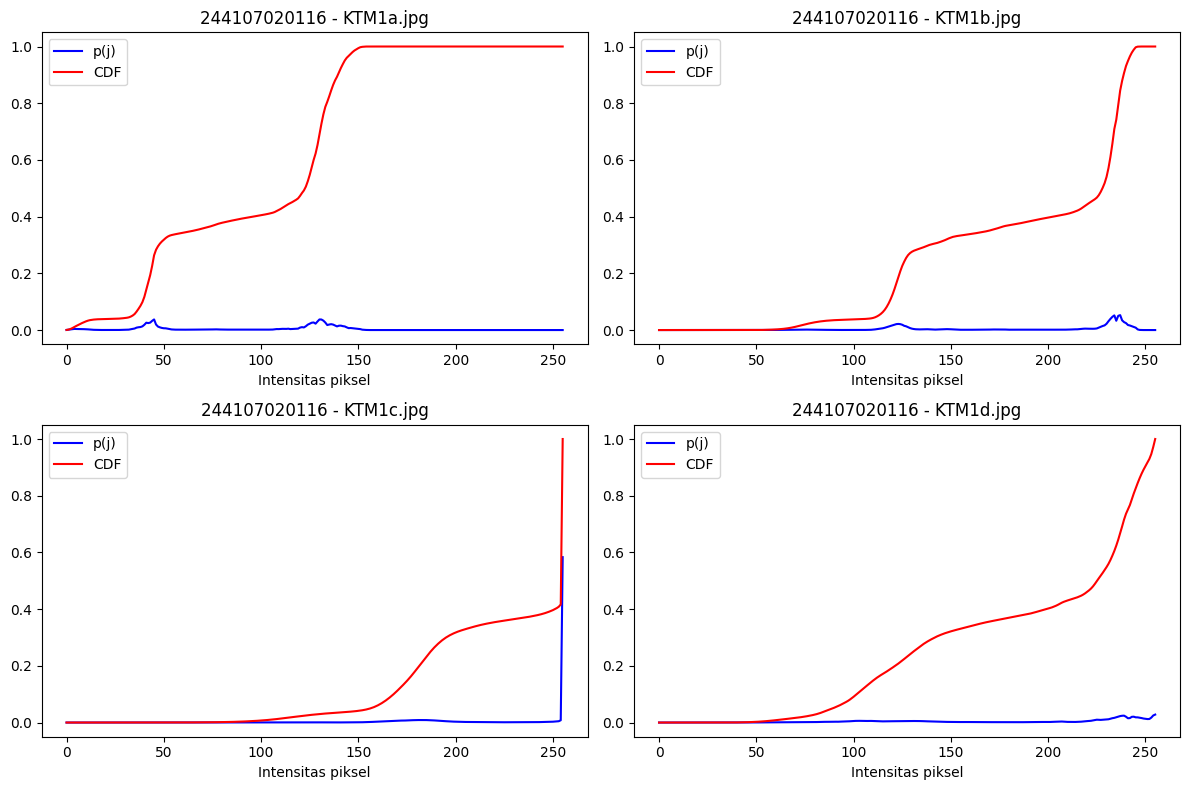

In [17]:
daftar_ktm = ['KTM1a.jpg', 'KTM1b.jpg', 'KTM1c.jpg', 'KTM1d.jpg']

fig, axs = plt.subplots(2, 2, figsize=(12, 8))
axs = axs.flatten()

for i, nama_file in enumerate(daftar_ktm):
    gray = cv.imread(PATH + '/' + nama_file, cv.IMREAD_GRAYSCALE)

    h = histogram_manual(gray)
    p = h / gray.size          # histogram ternormalisasi p(j)
    cdf = np.cumsum(p)         # distribusi kumulatif (CDF)

    axs[i].plot(p, color='blue', label='p(j)')
    axs[i].plot(cdf, color='red', label='CDF')
    axs[i].set_title(NIM + ' - ' + nama_file)
    axs[i].set_xlabel('Intensitas piksel')
    axs[i].legend()

plt.tight_layout()
plt.show()

**Penjelasan:**
- Pada citra paling gelap
kurva CDF naik tajam di sisi kiri (nilai intensitas rendah) lalu langsung mendatar, artinya hampir semua piksel bernilai gelap, sesuai dengan citra yang diambil di ruangan gelap.
- Pada citra paling terang, kurva CDF baru naik tajam di sisi kanan (nilai intensitas tinggi), sesuai dengan citra yang diambil dengan cahaya matahari langsung.

Jadi bisa kita simpulkan semakin gelap citra maka kurva CDF naik tajam disebelah kiri , dan semakin terang citra maka kurva CFD baru naik disisi kanan.

**3. Ulangi histogram `KTM1b.jpg` dengan jumlah bin = `PARAM['bins']` "
   "(nilai Anda) dan dengan 256 bin, tampilkan berdampingan.**

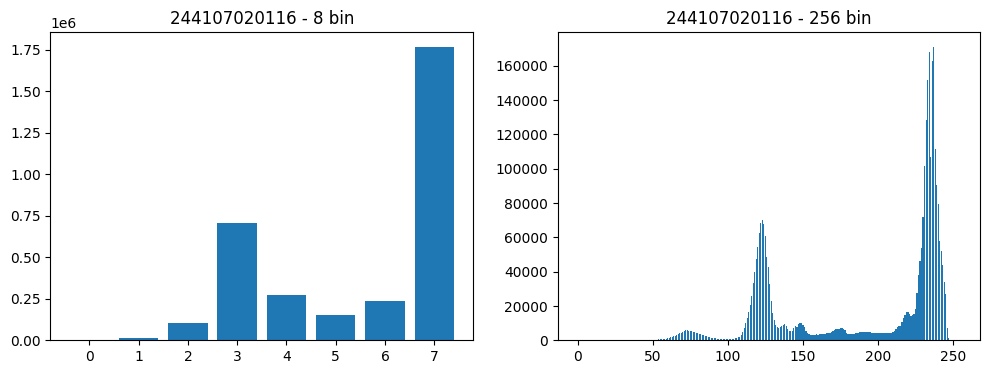

In [18]:
gray = cv.imread(PATH + '/KTM1b.jpg', cv.IMREAD_GRAYSCALE)

hist_sedikit_bin = cv.calcHist([gray], [0], None, [PARAM['bins']], [0, 256]).flatten()
hist_256_bin     = cv.calcHist([gray], [0], None, [256], [0, 256]).flatten()

fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].bar(range(PARAM['bins']), hist_sedikit_bin)
axs[0].set_title(NIM + f" - {PARAM['bins']} bin")
axs[1].bar(range(256), hist_256_bin)
axs[1].set_title(NIM + ' - 256 bin')
plt.show()

**Penjelasan:** semakin sedikit jumlah bin, semakin banyak nilai intensitas yang digabung menjadi satu batang. Detail sebaran kecerahan yang halus (perbedaan antar nilai piksel yang berdekatan) jadi hilang.

# E-2. PERCOBAAN HISTOGRAM EQUALIZATION

**1. Histogram equalization manual berdasarkan flowchart modul.**
Tahap 1 memakai `lena_lc.jpg` (citra contoh low-contrast), tahap 2 memakai `KTM1a.jpg`
(hasil akuisisi di ruangan gelap).

In [19]:
def equalize_manual_channel(channel):
    """Histogram equalization manual untuk 1 kanal, rumus Ko = round(CDF * (L-1))."""
    h = histogram_manual(channel)
    p = h / channel.size
    cdf = np.cumsum(p)
    L = 256
    tabel_transformasi = np.round(cdf * (L - 1)).astype(np.uint8)
    return tabel_transformasi[channel]   # terapkan tabel ke tiap piksel sekaligus

def equalize_manual_bgr(bgr):
    """Terapkan equalize_manual_channel ke tiap kanal B, G, R lalu digabung."""
    b, g, r = cv.split(bgr)
    return cv.merge([equalize_manual_channel(b),
                      equalize_manual_channel(g),
                      equalize_manual_channel(r)])

def proses_equalization(path_gambar, nama_file):
    bgr = cv.imread(path_gambar)
    hasil = equalize_manual_bgr(bgr)

    # citra sebelum vs sesudah
    fig, axs = plt.subplots(1, 2, figsize=(10, 5))
    axs[0].imshow(cv.cvtColor(bgr, cv.COLOR_BGR2RGB));   axs[0].set_title('Sebelum'); axs[0].axis('off')
    axs[1].imshow(cv.cvtColor(hasil, cv.COLOR_BGR2RGB)); axs[1].set_title('Sesudah'); axs[1].axis('off')
    fig.suptitle(NIM + ' - ' + nama_file)
    plt.show()

    # histogram RGB sebelum vs sesudah (2 baris x 3 kolom)
    warna = ['Biru', 'Hijau', 'Merah']
    matplotlib_colors = {'Biru': 'blue', 'Hijau': 'green', 'Merah': 'red'}
    fig, axs = plt.subplots(2, 3, figsize=(15, 6))
    for i, w in enumerate(warna):
        axs[0, i].bar(range(256), histogram_manual(cv.split(bgr)[i]), color=matplotlib_colors[w])
        axs[0, i].set_title('Sebelum - ' + w)
        axs[1, i].bar(range(256), histogram_manual(cv.split(hasil)[i]), color=matplotlib_colors[w])
        axs[1, i].set_title('Sesudah - ' + w)
    fig.suptitle('Histogram RGB plot')
    plt.tight_layout()
    plt.show()
    return bgr, hasil

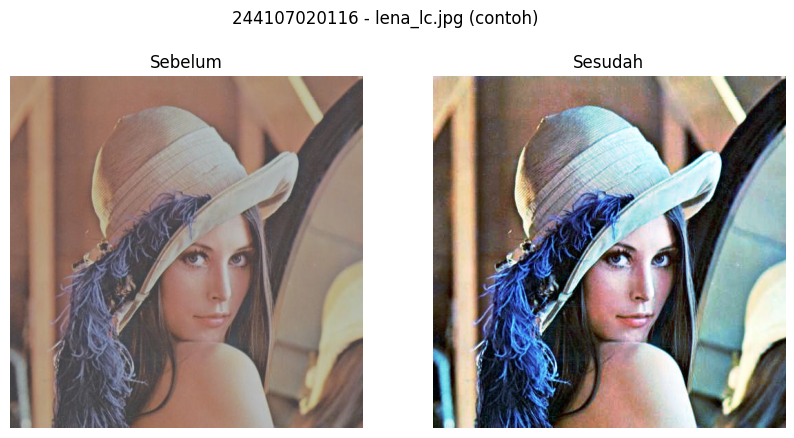

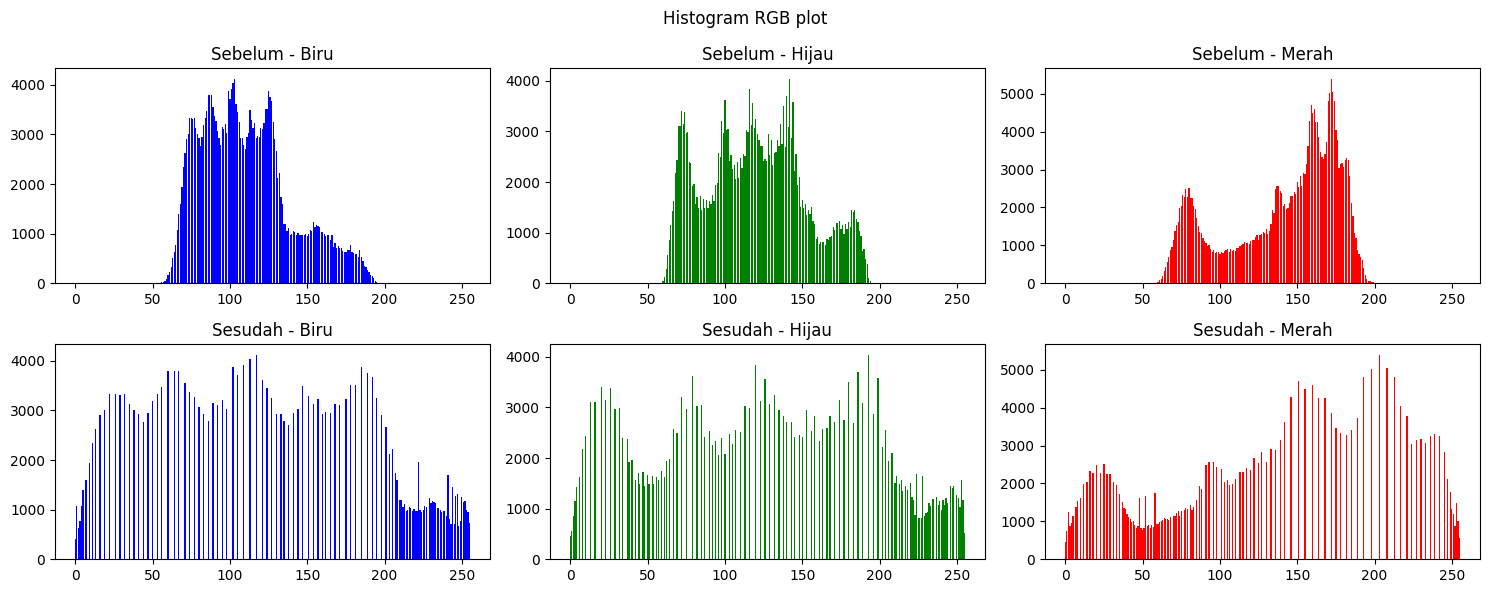

In [22]:
# Tahap 1: citra contoh
_ = proses_equalization(PATH + '/lena_lc.jpg', 'lena_lc.jpg (contoh)')

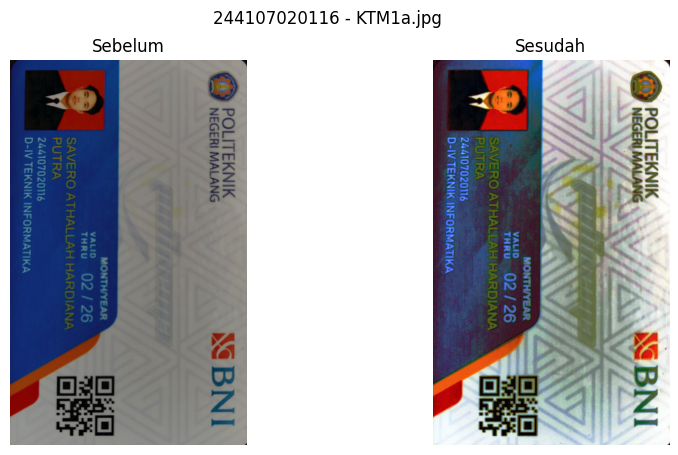

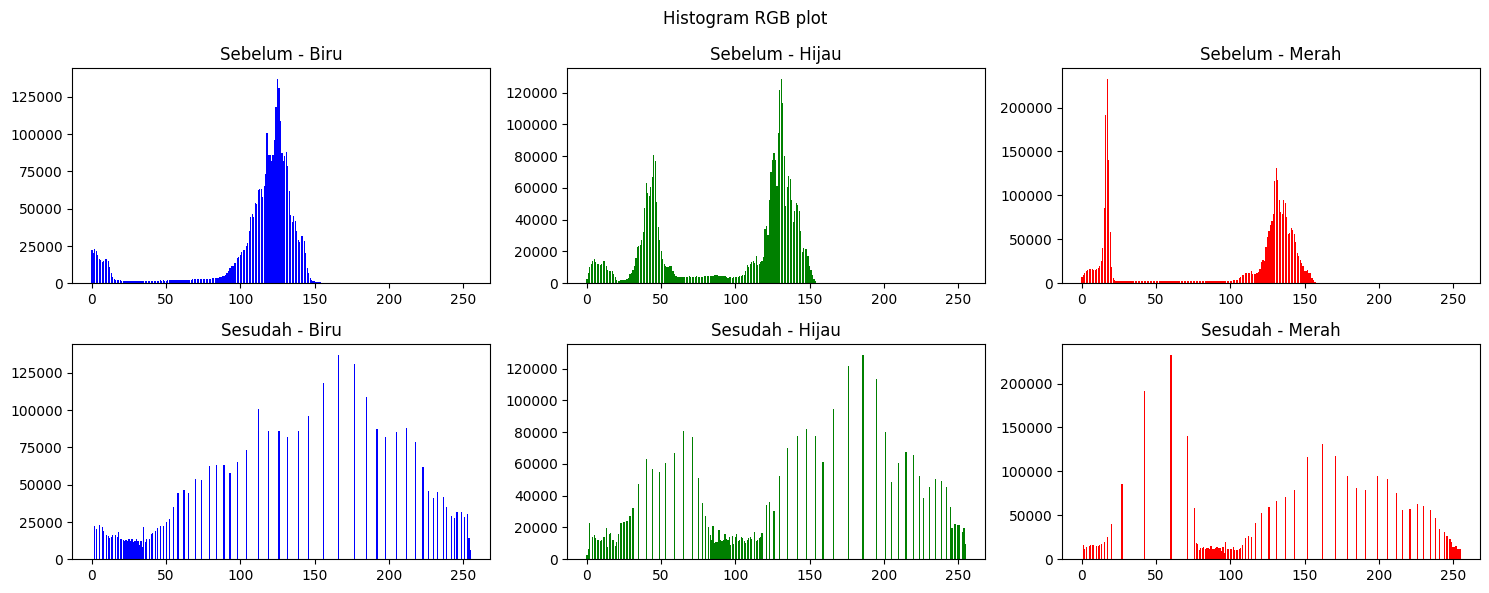

In [23]:
# Tahap 2: citra KTM milik sendiri
bgr_ktm1a, hasil_manual_ktm1a = proses_equalization(PATH + '/KTM1a.jpg', 'KTM1a.jpg')

**2. Bandingkan dengan `cv.equalizeHist` per kanal (selisih maksimum antara manual dan bawaan OpenCV).**

In [24]:
def bandingkan_equalize(path_gambar, nama_file):
    bgr = cv.imread(path_gambar)
    hasil_manual = equalize_manual_bgr(bgr)

    b, g, r = cv.split(bgr)
    hasil_cv = cv.merge([cv.equalizeHist(b), cv.equalizeHist(g), cv.equalizeHist(r)])

    selisih = np.max(np.abs(hasil_manual.astype(int) - hasil_cv.astype(int)))
    print(f'{nama_file}: selisih maksimum manual vs cv.equalizeHist (semua kanal) = {selisih}')

bandingkan_equalize(PATH + '/lena_lc.jpg', 'lena_lc.jpg')
bandingkan_equalize(PATH + '/KTM1a.jpg', 'KTM1a.jpg')

lena_lc.jpg: selisih maksimum manual vs cv.equalizeHist (semua kanal) = 1
KTM1a.jpg: selisih maksimum manual vs cv.equalizeHist (semua kanal) = 2


**Penjelasan bila selisih tidak nol:** `cv.equalizeHist` menggunakan rumus pembulatan yang sedikit berbeda (memakai nilai CDF minimum tak-nol sebagai   acuan, bukan langsung dari 0) serta pembulatan ke bawah pada bagian
   tertentu, sedangkan implementasi manual di atas membulatkan ke nilai
   terdekat (`np.round`). Perbedaan pembulatan inilah yang membuat hasil
   sedikit berbeda meski secara visual hampir tidak terlihat.

**3-4. Ekualisasi pada citra berwarna**: cara 1 (tiap kanal B, G, R diekualisasi sendiri-sendiri) dan cara 2 (hanya kanal kecerahan yang diekualisasi, pada ruang warna YCrCb / HSV / LAB). Tahap 1 pakai `lena.jpg`, tahap 2 pakai `KTM1d.jpg`.

In [25]:
def equalisasi_warna(path_gambar, nama_file):
    bgr = cv.imread(path_gambar)

    # cara 1: tiap kanal B, G, R diekualisasi sendiri-sendiri
    kanal = list(cv.split(bgr))
    for i in range(3):
        kanal[i] = cv.equalizeHist(kanal[i])
    he_rgb = cv.merge(kanal)

    # cara 2: hanya kanal kecerahan yang diekualisasi (warna asli tidak disentuh)
    ycrcb = cv.cvtColor(bgr, cv.COLOR_BGR2YCrCb)
    y, cr, cb = cv.split(ycrcb)
    he_y = cv.cvtColor(cv.merge([cv.equalizeHist(y), cr, cb]), cv.COLOR_YCrCb2BGR)

    hsv = cv.cvtColor(bgr, cv.COLOR_BGR2HSV)
    h, s, v = cv.split(hsv)
    he_v = cv.cvtColor(cv.merge([h, s, cv.equalizeHist(v)]), cv.COLOR_HSV2BGR)

    lab = cv.cvtColor(bgr, cv.COLOR_BGR2LAB)
    l, a, b = cv.split(lab)
    he_l = cv.cvtColor(cv.merge([cv.equalizeHist(l), a, b]), cv.COLOR_LAB2BGR)

    judul = ['Asli', 'Ekualisasi B, G, R', 'Kanal Y', 'Kanal V', 'Kanal L']
    citra = [bgr, he_rgb, he_y, he_v, he_l]

    plt.figure(figsize=(18, 4))
    for i, (c, t) in enumerate(zip(citra, judul), 1):
        plt.subplot(1, 5, i)
        plt.imshow(cv.cvtColor(c, cv.COLOR_BGR2RGB))
        plt.title(NIM + ' - ' + t, fontsize=9)
        plt.axis('off')
    plt.suptitle(nama_file)
    plt.show()

    return bgr, judul, citra

def geser_hue(asli, hasil):
    """Rata-rata pergeseran Hue (Hue melingkar 0-179 di OpenCV)."""
    h1 = cv.cvtColor(asli, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    h2 = cv.cvtColor(hasil, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    d = np.abs(h1 - h2)
    d = np.minimum(d, 180 - d)
    return d.mean()

def cetak_tabel_hue(bgr, judul, citra):
    print('%-22s %16s %16s' % ('Cara', 'geser Hue (der)', 'rerata terang'))
    for t, c in zip(judul, citra):
        print('%-22s %16.2f %16.1f' % (
            t, geser_hue(bgr, c) * 2, cv.cvtColor(c, cv.COLOR_BGR2GRAY).mean()))

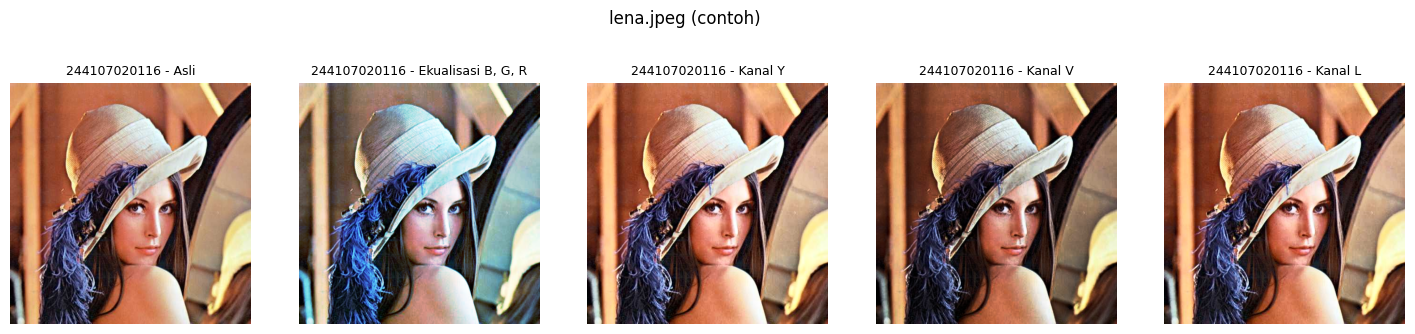

Cara                    geser Hue (der)    rerata terang
Asli                               0.00            122.2
Ekualisasi B, G, R                53.03            127.4
Kanal Y                            0.40            127.9
Kanal V                            0.87            100.6
Kanal L                            1.65            122.7


In [27]:
# Tahap 1: citra contoh
bgr, judul, citra = equalisasi_warna(PATH + '/lena.jpeg', 'lena.jpeg (contoh)')
cetak_tabel_hue(bgr, judul, citra)

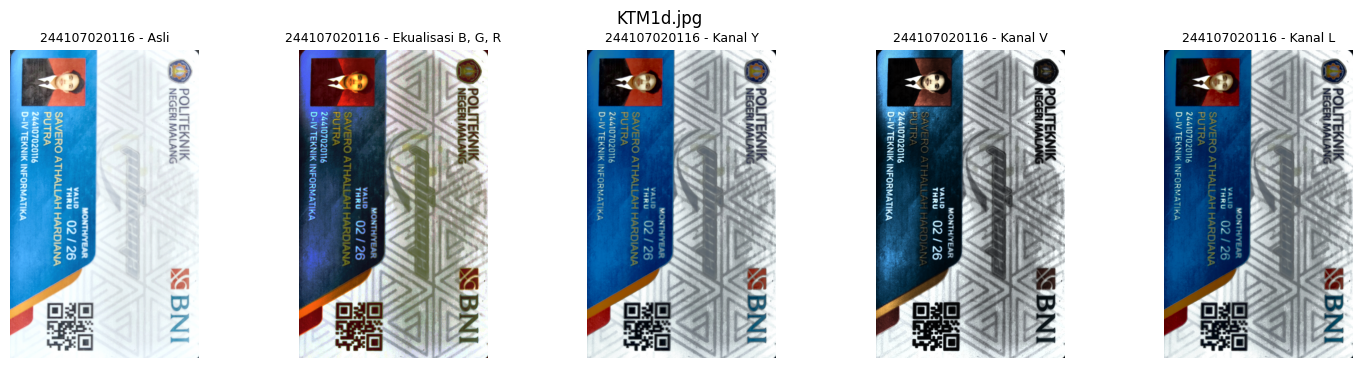

Cara                    geser Hue (der)    rerata terang
Asli                               0.00            192.1
Ekualisasi B, G, R                67.47            129.3
Kanal Y                            2.48            132.2
Kanal V                            2.90            118.1
Kanal L                            6.09            122.8


In [28]:
# Tahap 2: citra KTM milik sendiri
bgr_ktm, judul_ktm, citra_ktm = equalisasi_warna(PATH + '/KTM1d.jpg', 'KTM1d.jpg')
cetak_tabel_hue(bgr_ktm, judul_ktm, citra_ktm)

**Catat angka dari tabel yang tercetak di atas (KTM1d.jpg) ke tabel laporan Anda, "
   "lalu jawab:**

1. **Cara mana yang menghasilkan pergeseran Hue paling besar?**  cara 1
   (ekualisasi kanal B, G, R sendiri-sendiri), karena tiap kanal warna diubah
   secara independen, sehingga proporsi antar warna
   ikut berubah.
2. **Mengapa ekualisasi kanal terang tetap menghasilkan pergeseran Hue yang tidak persis nol?** Karena saat citra dikembalikan ke ruang warna BGR, nilai
   piksel dibulatkan dan dipotong (clip) ke rentang 0-255, sehingga muncul
   sedikit galat pembulatan yang menggeser Hue meskipun kanal warna (Cr/Cb,
   Hue/Saturation, A/B) sengaja tidak diubah.
3. **Kanal mana (Y, V, atau L) yang paling sesuai untuk foto KTM Anda?**
kanal L (LAB) atau Y (YCrCb) paling stabil warnanya.
4. **Bandingkan dengan CLAHE .**

Kanal Y + equalizeHist biasa:
  geser Hue     : 2.48
  rerata terang : 132.2
Kanal Y + CLAHE:
  geser Hue     : 0.83
  rerata terang : 174.4


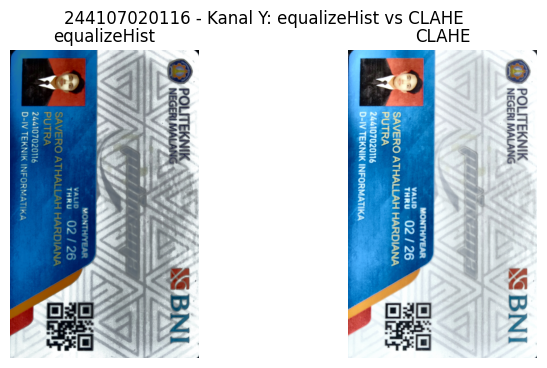

In [29]:
# Ulangi salah satu cara (kanal Y) dengan CLAHE, bandingkan dengan equalizeHist biasa
clahe = cv.createCLAHE(clipLimit=PARAM['clip'], tileGridSize=(PARAM['tile'], PARAM['tile']))

ycrcb = cv.cvtColor(bgr_ktm, cv.COLOR_BGR2YCrCb)
y, cr, cb = cv.split(ycrcb)
he_clahe = cv.cvtColor(cv.merge([clahe.apply(y), cr, cb]), cv.COLOR_YCrCb2BGR)

print('Kanal Y + equalizeHist biasa:')
print('  geser Hue     :', round(geser_hue(bgr_ktm, citra_ktm[2]) * 2, 2))
print('  rerata terang :', round(cv.cvtColor(citra_ktm[2], cv.COLOR_BGR2GRAY).mean(), 1))
print('Kanal Y + CLAHE:')
print('  geser Hue     :', round(geser_hue(bgr_ktm, he_clahe) * 2, 2))
print('  rerata terang :', round(cv.cvtColor(he_clahe, cv.COLOR_BGR2GRAY).mean(), 1))

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1); plt.imshow(cv.cvtColor(citra_ktm[2], cv.COLOR_BGR2RGB)); plt.title('equalizeHist'); plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(cv.cvtColor(he_clahe, cv.COLOR_BGR2RGB));     plt.title('CLAHE');        plt.axis('off')
plt.suptitle(NIM + ' - Kanal Y: equalizeHist vs CLAHE')
plt.show()

CLAHE memberi pergeseran Hue lebih kecil dan kecerahan yang lebih halus dibanding `equalizeHist` biasa, karena CLAHE membatasi seberapa agresif histogram diratakan (dibatasi oleh `clipLimit`) sehingga perubahan warnanya lebih terkendali.

## Pertanyaan Praktikum E-2

**1. Ekualisasi global pada `KTM1a.jpg` (grayscale): manual dan `cv.equalizeHist`, tampilkan asli + hasil + histogram, lalu hitung PSNR.**

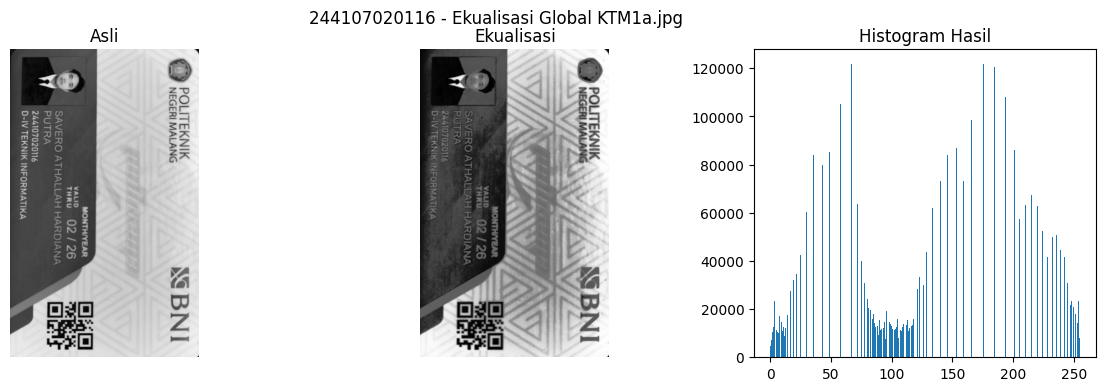

PSNR asli vs hasil ekualisasi manual: 14.34 dB
PSNR asli vs hasil ekualisasi cv: 14.34 dB


In [30]:
def hitung_psnr(asli, hasil):
    mse = np.mean((asli.astype(np.float64) - hasil.astype(np.float64)) ** 2)
    if mse == 0:
        return float('inf')
    return 10 * np.log10((255.0 ** 2) / mse)

gray_a = cv.imread(PATH + '/KTM1a.jpg', cv.IMREAD_GRAYSCALE)
hasil_manual_a = equalize_manual_channel(gray_a)
hasil_cv_a = cv.equalizeHist(gray_a)

fig, axs = plt.subplots(1, 3, figsize=(15, 4))
axs[0].imshow(gray_a, cmap='gray');        axs[0].set_title('Asli');       axs[0].axis('off')
axs[1].imshow(hasil_cv_a, cmap='gray');    axs[1].set_title('Ekualisasi'); axs[1].axis('off')
axs[2].bar(range(256), histogram_manual(hasil_cv_a))
axs[2].set_title('Histogram Hasil')
fig.suptitle(NIM + ' - Ekualisasi Global KTM1a.jpg')
plt.show()

psnr_manual = hitung_psnr(gray_a, hasil_manual_a)
psnr_cv = hitung_psnr(gray_a, hasil_cv_a)
print('PSNR asli vs hasil ekualisasi manual:', round(psnr_manual, 2), 'dB')
print('PSNR asli vs hasil ekualisasi cv:', round(psnr_cv, 2), 'dB')

**Mengapa PSNR justru turun padahal citra terlihat lebih jelas?** karena PSNR cocok untuk mengukur kehilangan informasi akibat kompresi/noise, tapi **tidak cocok** untuk menilai keterbacaan atau kualitas visual hasil perbaikan citra seperti histogram equalization.

**2. Ekualisasi lokal dengan CLAHE pada `KTM1a.jpg`.**

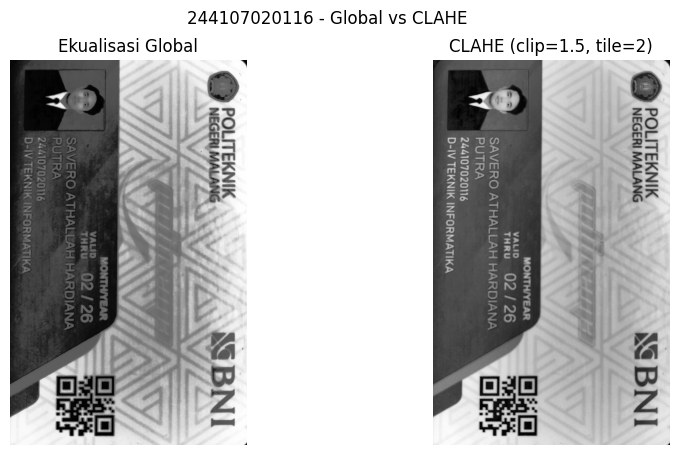

In [31]:
clahe_default = cv.createCLAHE(clipLimit=PARAM['clip'], tileGridSize=(PARAM['tile'], PARAM['tile']))
hasil_clahe_a = clahe_default.apply(gray_a)

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(hasil_cv_a, cmap='gray');    axs[0].set_title('Ekualisasi Global'); axs[0].axis('off')
axs[1].imshow(hasil_clahe_a, cmap='gray'); axs[1].set_title(f"CLAHE (clip={PARAM['clip']}, tile={PARAM['tile']})"); axs[1].axis('off')
fig.suptitle(NIM + ' - Global vs CLAHE')
plt.show()

Pada hasil CLAHE Gambar udah terbaca dengan jelas

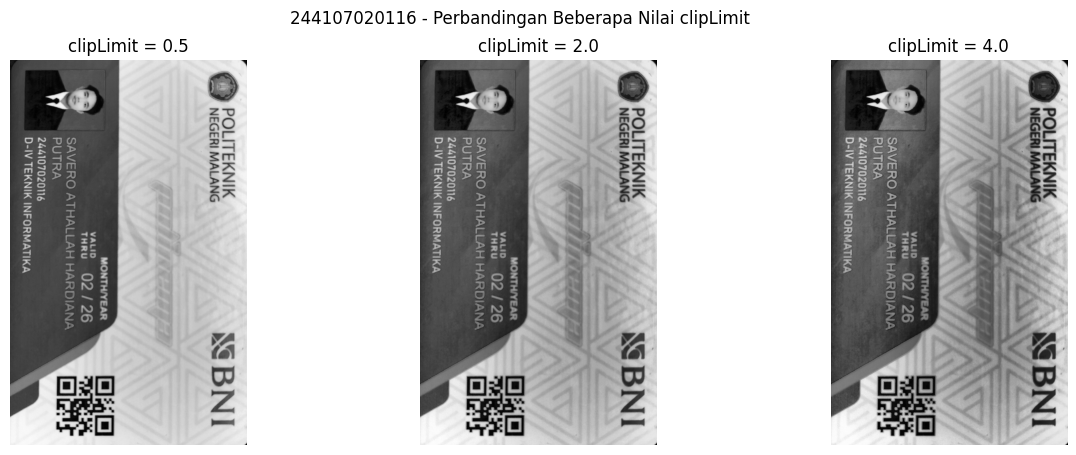

In [32]:
nilai_clip_lain = [0.5, 2.0, 4.0]

fig, axs = plt.subplots(1, len(nilai_clip_lain), figsize=(15, 5))
for i, clip in enumerate(nilai_clip_lain):
    clahe_coba = cv.createCLAHE(clipLimit=clip, tileGridSize=(PARAM['tile'], PARAM['tile']))
    hasil = clahe_coba.apply(gray_a)
    axs[i].imshow(hasil, cmap='gray')
    axs[i].set_title(f'clipLimit = {clip}')
    axs[i].axis('off')
fig.suptitle(NIM + ' - Perbandingan Beberapa Nilai clipLimit')
plt.show()

Jadi mennurut saya cliplimit 1 adalah yagn terbaik, karena balence, hasil halus  dan kontrasnya  tidak terlalu kuat.

- semakin besar `clipLimit`, semakin kuat kontras yang dihasilkan tetapi noise/bintik pada area yang datar (misalnya latar belakang KTM) juga semakin terlihat.

- Semakin kecil `clipLimit`, hasilnya lebih halus tapi peningkatan kontrasnya kurang terasa.


# E-3. TUGAS PRAKTIKUM DITHERING

**1. Dithering Floyd-Steinberg.**


In [33]:
def floyd_steinberg(channel, L=2):
    """Dithering error-diffusion Floyd-Steinberg untuk 1 kanal (sesuai rumus modul)."""
    img = channel.astype(np.float32).copy()
    step = 255.0 / (L - 1)
    H, W = img.shape
    for y in range(H):
        for x in range(W):
            lama = img[y, x]
            baru = np.round(lama / step) * step   # warna palet terdekat
            img[y, x] = baru
            error = lama - baru
            if x + 1 < W:                 img[y, x + 1]     += error * 7 / 16
            if x > 0 and y + 1 < H:       img[y + 1, x - 1] += error * 3 / 16
            if y + 1 < H:                 img[y + 1, x]     += error * 5 / 16
            if x + 1 < W and y + 1 < H:   img[y + 1, x + 1] += error * 1 / 16
    return np.clip(img, 0, 255).astype(np.uint8)

def dithering_bgr(bgr, L):
    """Terapkan floyd_steinberg ke tiap kanal B, G, R lalu digabung."""
    b, g, r = cv.split(bgr)
    return cv.merge([floyd_steinberg(b, L), floyd_steinberg(g, L), floyd_steinberg(r, L)])

def tampilkan_dithering(path_gambar, judul, L):
    bgr = cv.imread(path_gambar)
    hasil = dithering_bgr(bgr, L)

    fig, axs = plt.subplots(1, 2, figsize=(10, 5))
    axs[0].imshow(cv.cvtColor(bgr, cv.COLOR_BGR2RGB));   axs[0].set_title('Sebelum'); axs[0].axis('off')
    axs[1].imshow(cv.cvtColor(hasil, cv.COLOR_BGR2RGB)); axs[1].set_title(f'Sesudah (L={L})'); axs[1].axis('off')
    fig.suptitle(judul)
    plt.show()
    return bgr, hasil

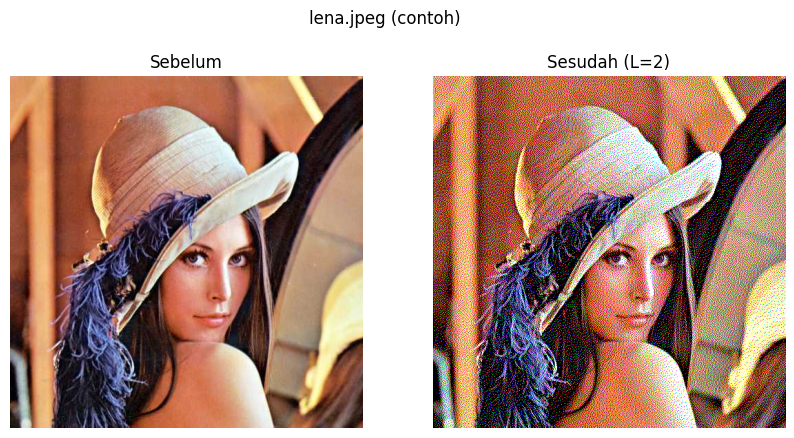

In [35]:
# Tahap 1: citra contoh (L=2 sesuai contoh pada modul)
_ = tampilkan_dithering(PATH + '/lena.jpeg', 'lena.jpeg (contoh)', L=2)

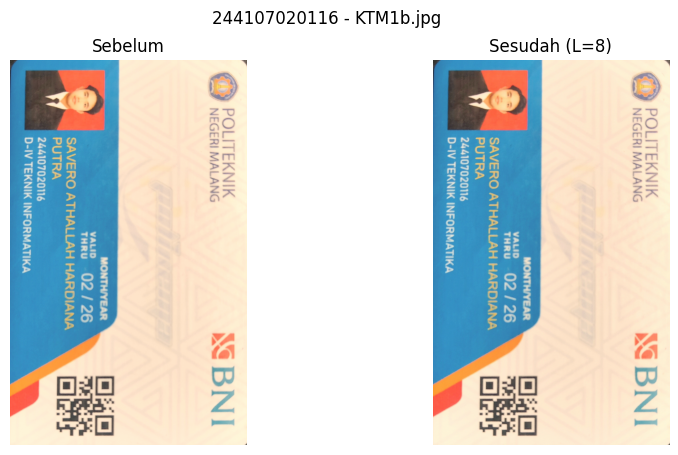

In [36]:
# Tahap 2: citra KTM milik sendiri, dengan jumlah level PARAM['L']
_ = tampilkan_dithering(PATH + '/KTM1b.jpg', NIM + ' - KTM1b.jpg', L=PARAM['L'])

**2.**

In [37]:
def bandingkan_dithering(path_gambar, judul, L):
    gray = cv.imread(path_gambar, cv.IMREAD_GRAYSCALE)

    # jalur 1: dithering langsung tanpa ekualisasi
    dither_langsung = floyd_steinberg(gray, L=L)

    # jalur 2: ekualisasi dulu, baru dithering
    gray_equalized = cv.equalizeHist(gray)
    dither_setelah_equalisasi = floyd_steinberg(gray_equalized, L=L)

    fig, axs = plt.subplots(1, 2, figsize=(10, 5))
    axs[0].imshow(dither_langsung, cmap='gray')
    axs[0].set_title('Dithering langsung'); axs[0].axis('off')
    axs[1].imshow(dither_setelah_equalisasi, cmap='gray')
    axs[1].set_title('Ekualisasi lalu dithering'); axs[1].axis('off')
    fig.suptitle(judul)
    plt.show()

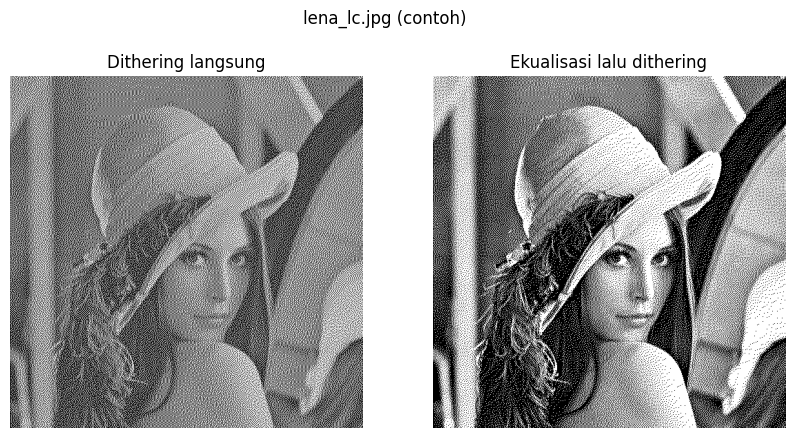

In [38]:
# Tahap 1: citra contoh
bandingkan_dithering(PATH + '/lena_lc.jpg', 'lena_lc.jpg (contoh)', L=2)

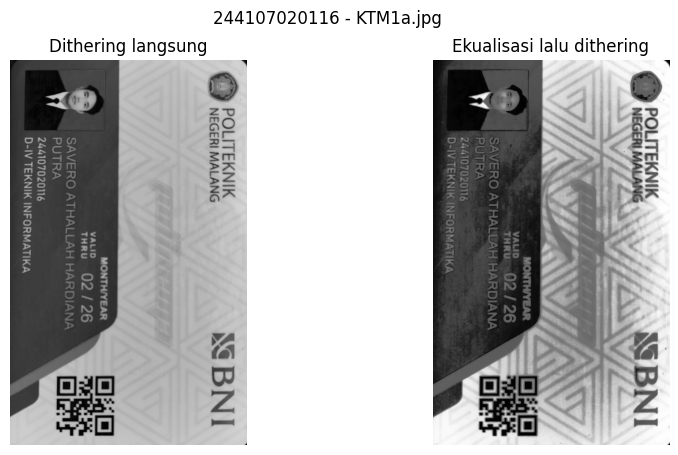

In [39]:
# Tahap 2: citra KTM milik sendiri
bandingkan_dithering(PATH + '/KTM1a.jpg', NIM + ' - KTM1a.jpg', L=PARAM['L'])

- Dethering lalngsung:
Hasil: Karena kontras awalnya rendah, banyak area gelap memiliki nilai piksel yang sangat mirip. Ketika dithering diterapkan, perbedaan halus ini mungkin tidak cukup untuk menghasilkan pola yang jelas, sehingga teks menjadi kurang terbaca.

- Ekualiasasi lalu dathering:
Dengan kontras yang sudah ditingkatkan oleh ekualisasi, dithering memiliki informasi perbedaan intensitas yang lebih jelas untuk dikerjakan. Ini memungkinkan algoritma dithering untuk merepresentasikan detail teks dengan lebih baik, karena perbedaan antara area terang dan gelap pada teks menjadi lebih menonjol. Akibatnya, teks pada gambar KTM menjadi lebih terbaca.